# Matting Quality Assessment Metrics

This notebook calculates and compares quality metrics for three different matting approaches:
1. **Ground Truth (GT)**
2. **MAP Solution**
3. **NN Solution (U-Net)**

The metrics used are:
- **Mean Squared Error (MSE)**
- **Structural Similarity Index (SSIM)**
- **Intersection over Union (IoU)**

In [32]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Paths
GT_DIR = 'ground truth'
MAP_DIR = 'map_mattes'
NN_DIR = 'nn_mattes'

GT_COMP_DIR = os.path.join(GT_DIR, 'composite')
MAP_COMP_DIR = os.path.join(MAP_DIR, 'composite')
NN_COMP_DIR = os.path.join(NN_DIR, 'composite')

In [33]:
def calculate_mse(img1, img2):
    return np.mean((img1.astype(np.float32) - img2.astype(np.float32))**2)

def calculate_ssim(img1, img2):
    if len(img1.shape) == 3:
        return ssim(img1, img2, channel_axis=2, data_range=255)
    else:
        return ssim(img1, img2, data_range=255)

def calculate_iou(mask1, mask2, threshold=128):
    m1 = (mask1 > threshold).astype(np.uint8)
    m2 = (mask2 > threshold).astype(np.uint8)
    intersection = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    if union == 0: return 1.0
    return intersection / union

In [34]:
gt_files = [f for f in os.listdir(GT_DIR) if f.endswith('.png')]
frames = []
for f in gt_files:
    parts = f.split('.')
    if len(parts) >= 2:
        frame_num = parts[-2]
        frames.append(frame_num)
frames.sort() # Ensure chronological order
print(f"Frames to analyze: {frames}")

Frames to analyze: ['00047', '00048', '00049']


In [35]:
results = []

for frame_str in frames:
    try: frame_int = int(frame_str)
    except ValueError: continue
        
    f5 = f"{frame_int:05d}"
    f4 = f"{frame_int:04d}"
    
    gt_matte_path = os.path.join(GT_DIR, f'Hula.Fore.ACKGT.{f5}.png')
    map_matte_path = os.path.join(MAP_DIR, f'Hula.{f4}.png')
    nn_matte_path = os.path.join(NN_DIR, f'Hula.{f4}.png')
    gt_comp_path = os.path.join(GT_COMP_DIR, f'Hula.{f4}.png')
    map_comp_path = os.path.join(MAP_COMP_DIR, f'Hula.{f4}.png')
    nn_comp_path = os.path.join(NN_COMP_DIR, f'Hula.{f4}.png')
    
    if not all(os.path.exists(p) for p in [gt_matte_path, map_matte_path, nn_matte_path, gt_comp_path, map_comp_path, nn_comp_path]):
        continue
        
    gt_matte = cv2.imread(gt_matte_path, cv2.IMREAD_GRAYSCALE)
    map_matte = cv2.imread(map_matte_path, cv2.IMREAD_GRAYSCALE)
    nn_matte = cv2.imread(nn_matte_path, cv2.IMREAD_GRAYSCALE)
    gt_comp = cv2.imread(gt_comp_path)
    map_comp = cv2.imread(map_comp_path)
    nn_comp = cv2.imread(nn_comp_path)
    
    h, w = gt_matte.shape
    if map_matte.shape != (h, w): map_matte = cv2.resize(map_matte, (w, h))
    if nn_matte.shape != (h, w): nn_matte = cv2.resize(nn_matte, (w, h))
    if gt_comp.shape[:2] != (h, w): gt_comp = cv2.resize(gt_comp, (w, h))
    if map_comp.shape[:2] != (h, w): map_comp = cv2.resize(map_comp, (w, h))
    if nn_comp.shape[:2] != (h, w): nn_comp = cv2.resize(nn_comp, (w, h))

    results.append({
        'Frame': frame_int,
        'MAP_Matte_MSE': calculate_mse(gt_matte, map_matte),
        'NN_Matte_MSE': calculate_mse(gt_matte, nn_matte),
        'MAP_Matte_SSIM': calculate_ssim(gt_matte, map_matte),
        'NN_Matte_SSIM': calculate_ssim(gt_matte, nn_matte),
        'MAP_Matte_IoU': calculate_iou(gt_matte, map_matte),
        'NN_Matte_IoU': calculate_iou(gt_matte, nn_matte),
        'MAP_Comp_MSE': calculate_mse(gt_comp, map_comp),
        'NN_Comp_MSE': calculate_mse(gt_comp, nn_comp),
        'MAP_Comp_SSIM': calculate_ssim(gt_comp, map_comp),
        'NN_Comp_SSIM': calculate_ssim(gt_comp, nn_comp)
    })

df = pd.DataFrame(results)
display(df)

,Frame,MAP_Matte_MSE,NN_Matte_MSE,MAP_Matte_SSIM,NN_Matte_SSIM,MAP_Matte_IoU,NN_Matte_IoU,MAP_Comp_MSE,NN_Comp_MSE,MAP_Comp_SSIM,NN_Comp_SSIM
0,47,626.425354,719.964478,0.981802,0.977419,0.937912,0.924511,34.823593,39.166786,0.985396,0.982864
1,48,755.661621,979.517700,0.979928,0.973921,0.922704,0.895185,41.720543,55.214245,0.984628,0.981367
2,49,1473.810791,1706.795532,0.963970,0.956666,0.860407,0.831379,72.044785,86.849220,0.976522,0.971548


## Performance Comparison Visualizations

Below we visualize the aggregated performance metrics and the frame-by-frame progression.

C:\Users\jjzsi\AppData\Local\Temp\ipykernel_18572\2034469747.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_iou, x='Solution', y='IoU', ax=axes[1], palette="magma")
C:\Users\jjzsi\AppData\Local\Temp\ipykernel_18572\2034469747.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_mse_matte, x='Solution', y='MSE', ax=axes[2], palette="rocket")
C:\Users\jjzsi\AppData\Local\Temp\ipykernel_18572\2034469747.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_mse_comp, x='Solution', y='MSE', ax=axes[3], 

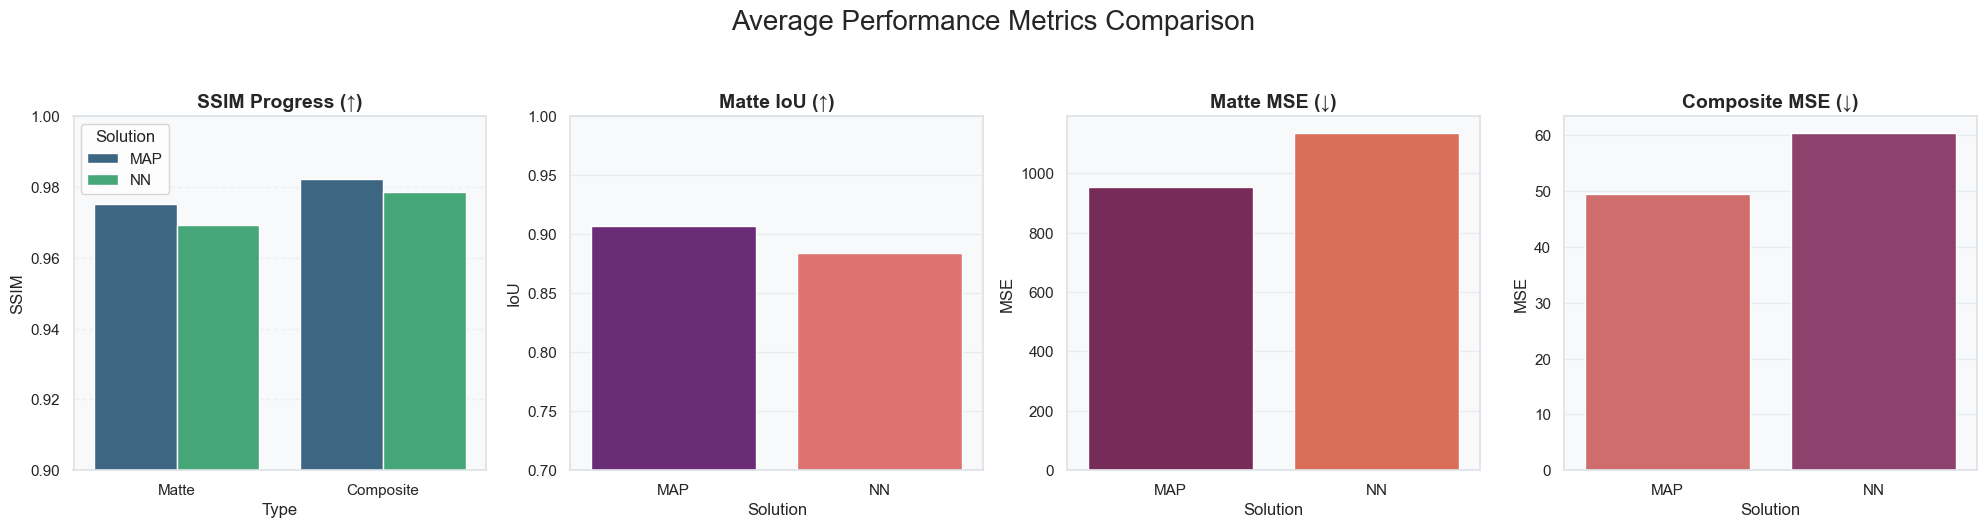

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Premium aesthetic settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.edgecolor': '#dee2e6',
    'grid.color': '#e9ecef',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'legend.frameon': True,
    'legend.facecolor': 'white'
})

# Calculate summary statistics
summary = df.mean(numeric_only=True).to_frame().T

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Average Performance Metrics Comparison", fontsize=20, y=1.05)

# 1. SSIM Comparison (Higher is better)
metrics_ssim = pd.DataFrame({
    'Solution': ['MAP', 'NN', 'MAP', 'NN'],
    'Type': ['Matte', 'Matte', 'Composite', 'Composite'],
    'SSIM': [
        summary['MAP_Matte_SSIM'][0], summary['NN_Matte_SSIM'][0],
        summary['MAP_Comp_SSIM'][0], summary['NN_Comp_SSIM'][0]
    ]
})
sns.barplot(data=metrics_ssim, x='Type', y='SSIM', hue='Solution', ax=axes[0], palette="viridis")
axes[0].set_title("SSIM Progress (↑)")
axes[0].set_ylim(0.9, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Matte IoU Comparison (Higher is better)
metrics_iou = pd.DataFrame({
    'Solution': ['MAP', 'NN'],
    'IoU': [summary['MAP_Matte_IoU'][0], summary['NN_Matte_IoU'][0]]
})
sns.barplot(data=metrics_iou, x='Solution', y='IoU', ax=axes[1], palette="magma")
axes[1].set_title("Matte IoU (↑)")
axes[1].set_ylim(0.7, 1.0)

# 3. Matte MSE Comparison (Lower is better)
metrics_mse_matte = pd.DataFrame({
    'Solution': ['MAP', 'NN'],
    'MSE': [summary['MAP_Matte_MSE'][0], summary['NN_Matte_MSE'][0]]
})
sns.barplot(data=metrics_mse_matte, x='Solution', y='MSE', ax=axes[2], palette="rocket")
axes[2].set_title("Matte MSE (↓)")

# 4. Composite MSE Comparison (Lower is better)
metrics_mse_comp = pd.DataFrame({
    'Solution': ['MAP', 'NN'],
    'MSE': [summary['MAP_Comp_MSE'][0], summary['NN_Comp_MSE'][0]]
})
sns.barplot(data=metrics_mse_comp, x='Solution', y='MSE', ax=axes[3], palette="flare")
axes[3].set_title("Composite MSE (↓)")

plt.tight_layout()
plt.show()

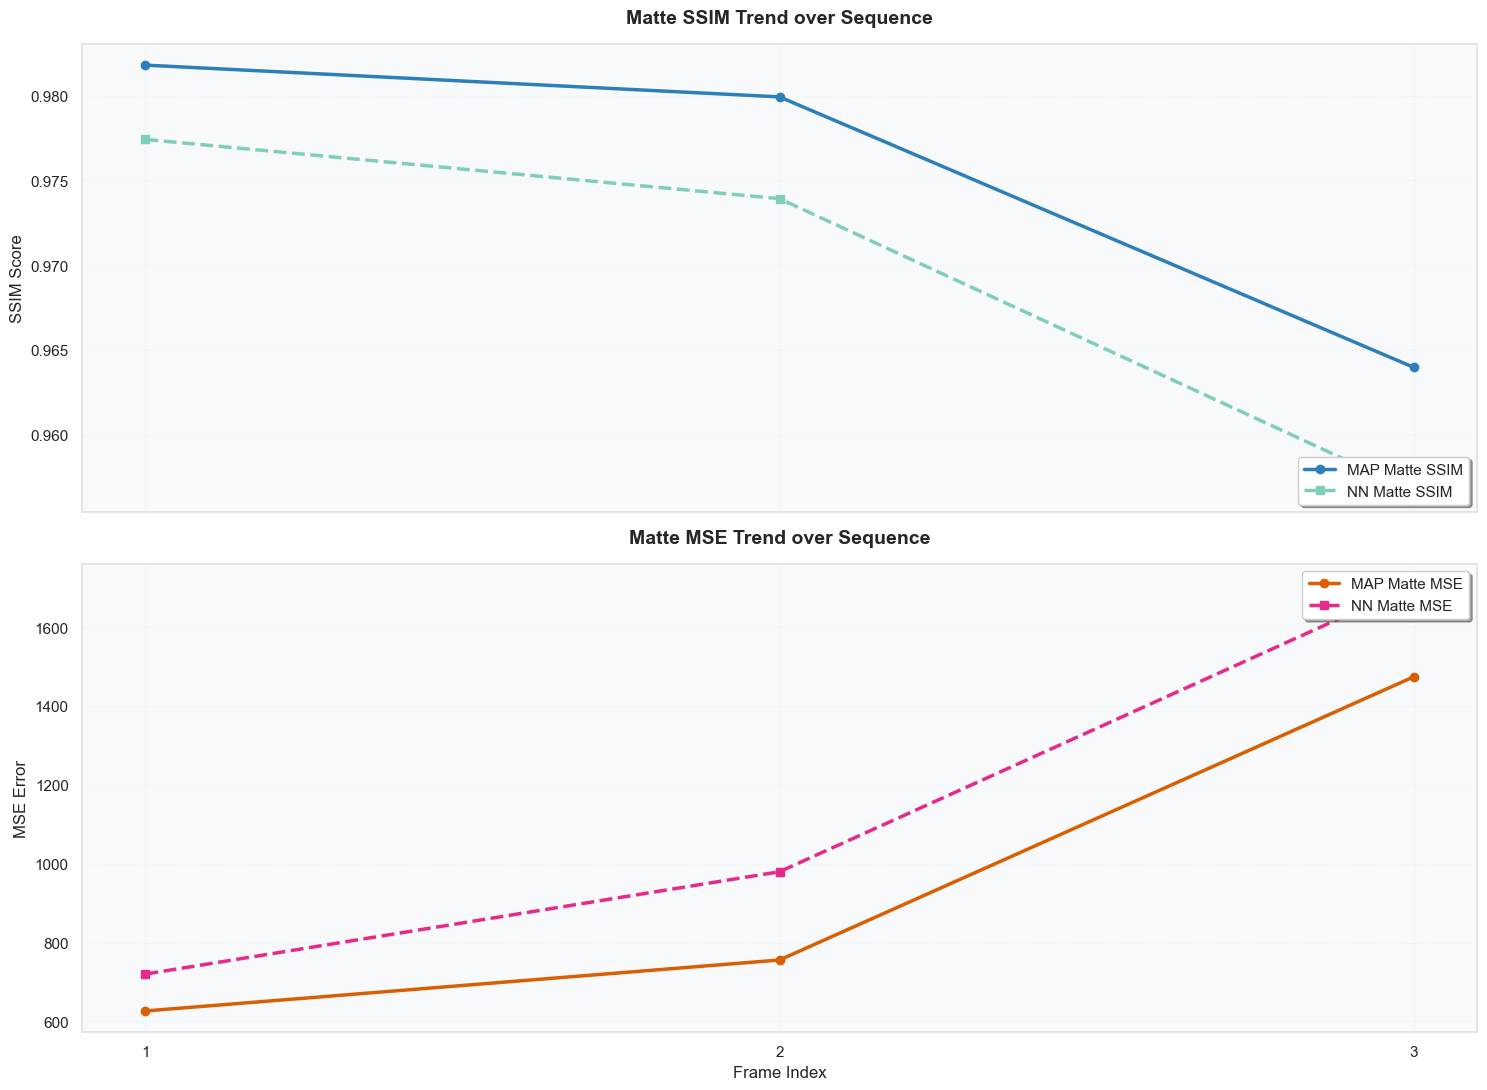

In [37]:
# Sequence Progression Trends
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Discrete x-axis (1, 2, 3...)
frame_indices = np.arange(1, len(df) + 1)

# Plot 1: SSIM Trends
axes[0].plot(frame_indices, df['MAP_Matte_SSIM'], marker='o', linewidth=2.5, label='MAP Matte SSIM', color='#2c7fb8')
axes[0].plot(frame_indices, df['NN_Matte_SSIM'], marker='s', linewidth=2.5, linestyle='--', label='NN Matte SSIM', color='#7fcdbb')
axes[0].set_title("Matte SSIM Trend over Sequence", pad=15)
axes[0].set_ylabel("SSIM Score")
axes[0].legend(loc='lower right', frameon=True, shadow=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: MSE Trends
axes[1].plot(frame_indices, df['MAP_Matte_MSE'], marker='o', linewidth=2.5, label='MAP Matte MSE', color='#d95f02')
axes[1].plot(frame_indices, df['NN_Matte_MSE'], marker='s', linewidth=2.5, linestyle='--', label='NN Matte MSE', color='#e7298a')
axes[1].set_title("Matte MSE Trend over Sequence", pad=15)
axes[1].set_ylabel("MSE Error")
axes[1].set_xlabel("Frame Index")
axes[1].legend(loc='upper right', frameon=True, shadow=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

# ENFORCE DISCRETE INTEGER TICKS (1, 2, 3...)
for ax in axes:
    ax.set_xticks(frame_indices)
    ax.set_xticklabels([str(i) for i in frame_indices])
    # Force ticks to be exactly the frame indices
    ax.xaxis.set_major_locator(plt.FixedLocator(frame_indices))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()